# 📊 Exploratory Data Analysis - Student Performance

## Project Overview

This project performs Exploratory Data Analysis (EDA) on a cleaned student performance dataset using Python, Pandas, Matplotlib, and Seaborn.

The objective is to explore the dataset, understand patterns and relationships, identify trends, and generate meaningful insights from student academic and attendance data.

## Objectives

- Understand the structure of the dataset
- Perform descriptive statistical analysis
- Analyze student academic performance
- Identify relationships between marks and attendance
- Create meaningful data visualizations
- Extract business-style insights from the data

## Technologies Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

===== EXPLORATORY DATA ANALYSIS =====

===== DATASET OVERVIEW =====
    Name  Age  Gender  Python  Math  Science  Attendance    City
0    Ved   21    Male    85.0  90.0     88.0        92.0  Nagpur
1  Rahul   22    Male    72.0  68.0     75.0        85.0    Pune
2  Priya   21  Female    95.0  92.0     96.0        98.0  Mumbai
3   Aman   23    Male    65.0  86.0     60.0        78.0  Nagpur
4   Neha   21  Female    80.0  85.0     82.0        90.0    Pune

Dataset Shape: (13, 8)

Columns:
['Name', 'Age', 'Gender', 'Python', 'Math', 'Science', 'Attendance', 'City']

Data Types:
Name              str
Age             int64
Gender            str
Python        float64
Math          float64
Science       float64
Attendance    float64
City              str
dtype: object

Missing Values:
Name          0
Age           0
Gender        0
Python        0
Math          0
Science       0
Attendance    0
City          0
dtype: int64

Duplicate Records:
0

===== DESCRIPTIVE STATISTICS =====
            

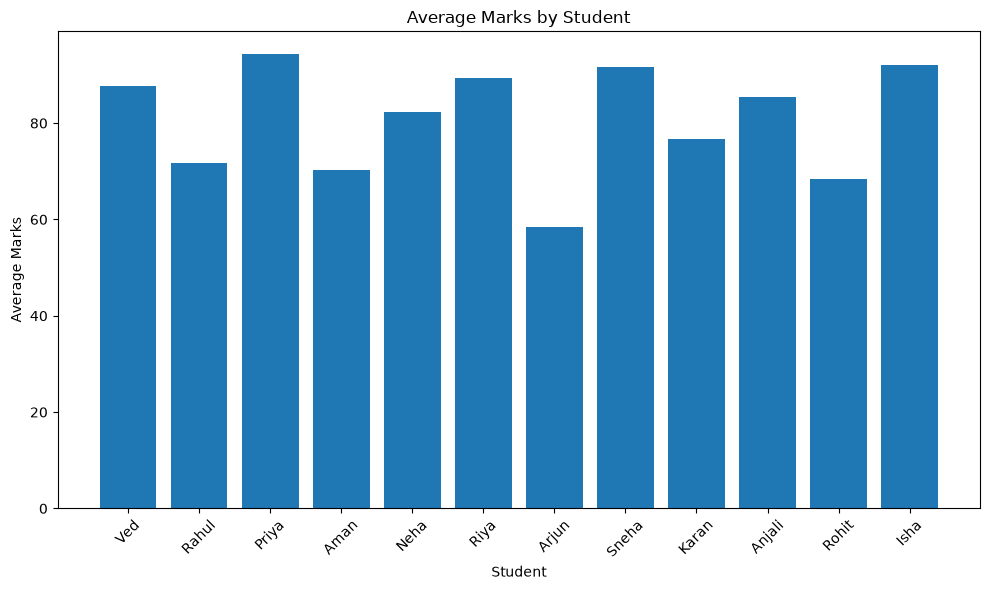

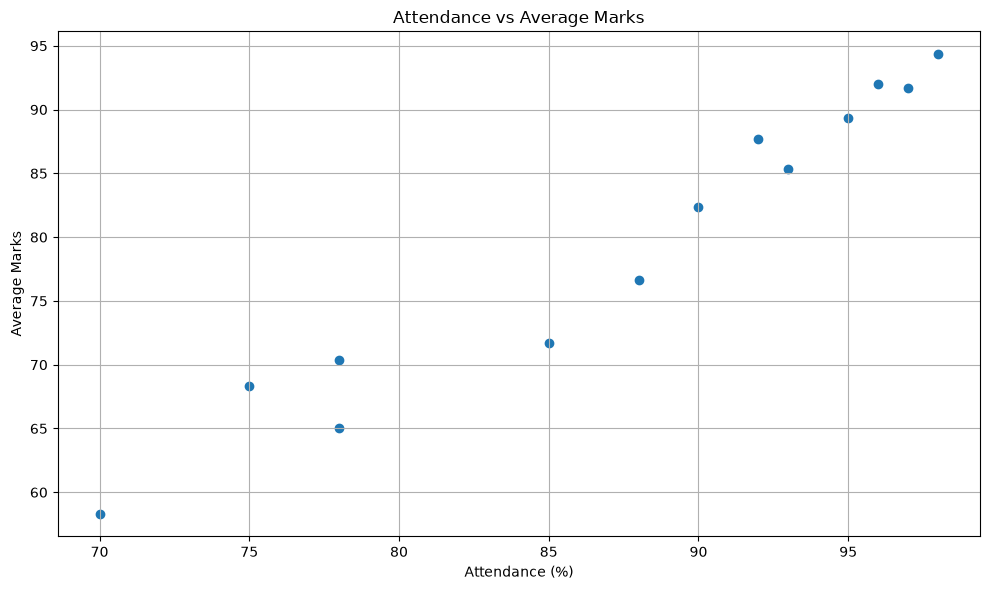

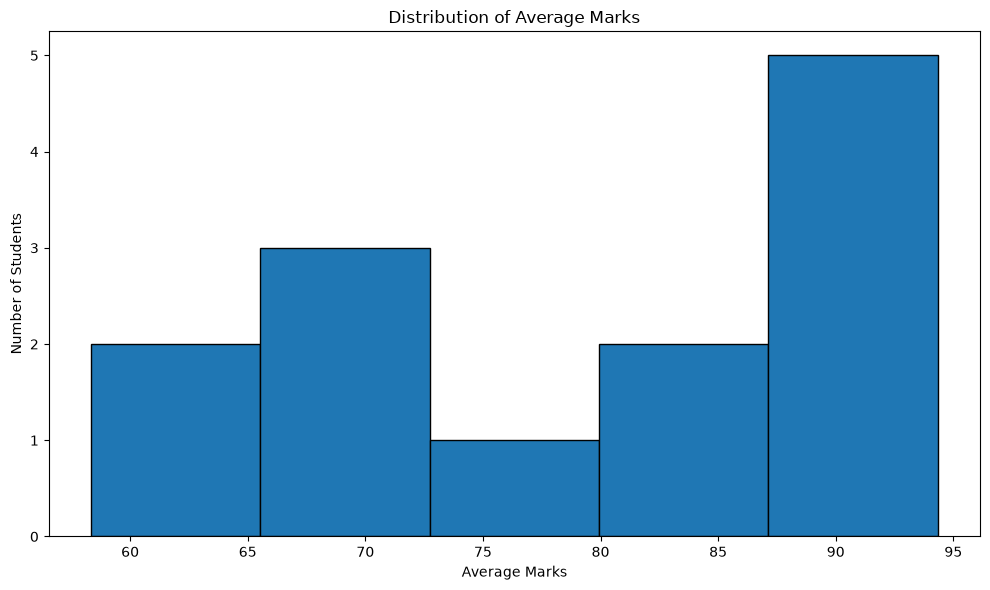

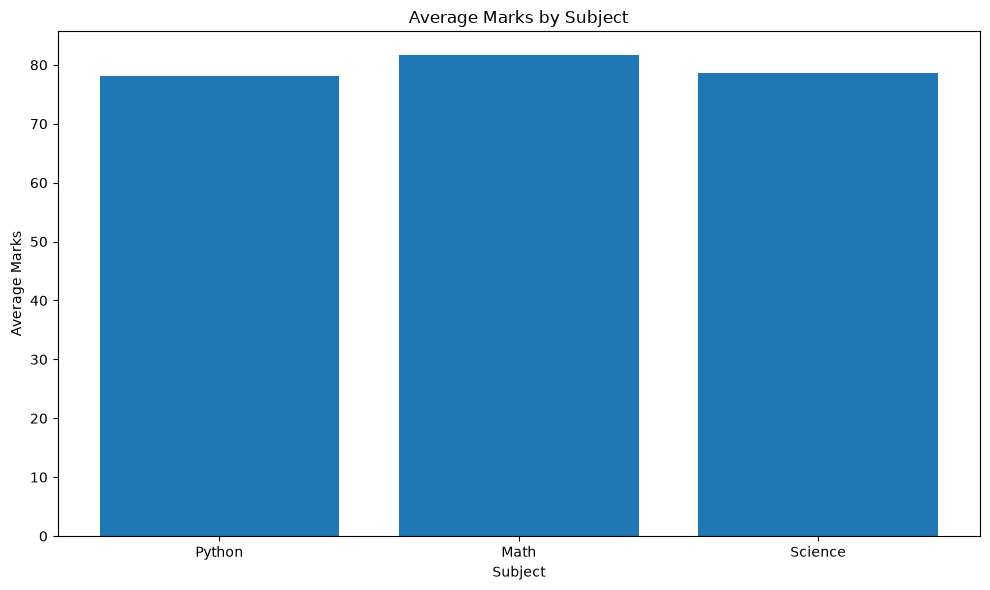

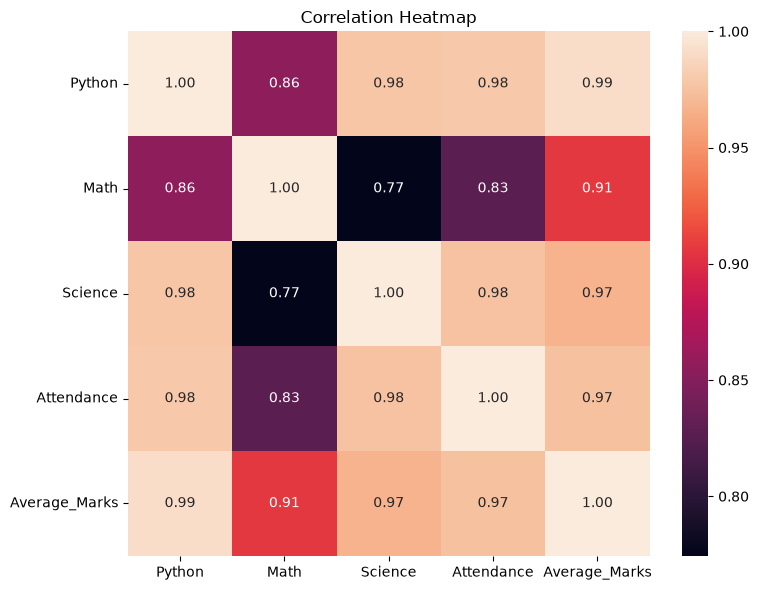


===== 5 BUSINESS INSIGHTS =====
1. The highest-performing student is Priya with an average score of 94.33 .
2. The lowest-performing student is Arjun with an average score of 58.33 .
3. Attendance ranges from 70.0 % to 98.0 % across the dataset.
4. The strongest-performing subject based on class average is Math with an average score of 81.62 .
5. The correlation between attendance and average marks is 0.97 , indicating the strength and direction of their relationship.

===== EDA SUMMARY =====
Total Students: 13
Average Student Score: 79.46
Average Attendance: 87.31 %
Highest Average Score: 94.33
Lowest Average Score: 58.33


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_students.csv")

print("===== EXPLORATORY DATA ANALYSIS =====")

print("\n===== DATASET OVERVIEW =====")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe())

print("\n===== ACADEMIC STATISTICS =====")
print("Python Average:", round(df["Python"].mean(), 2))
print("Math Average:", round(df["Math"].mean(), 2))
print("Science Average:", round(df["Science"].mean(), 2))
print("Attendance Average:", round(df["Attendance"].mean(), 2))

print("\nHighest Python Score:", df["Python"].max())
print("Highest Math Score:", df["Math"].max())
print("Highest Science Score:", df["Science"].max())
print("Highest Attendance:", df["Attendance"].max())

df["Total_Marks"] = df["Python"] + df["Math"] + df["Science"]
df["Average_Marks"] = df["Total_Marks"] / 3

print("\n===== STUDENT PERFORMANCE =====")
print(df[["Name", "Python", "Math", "Science", "Total_Marks", "Average_Marks", "Attendance"]].sort_values("Average_Marks", ascending=False))

print("\n===== TOP PERFORMERS =====")
print(df.nlargest(3, "Average_Marks")[["Name", "Average_Marks", "Attendance"]])

print("\n===== LOWEST PERFORMERS =====")
print(df.nsmallest(3, "Average_Marks")[["Name", "Average_Marks", "Attendance"]])

print("\n===== CORRELATION MATRIX =====")
correlation = df[["Python", "Math", "Science", "Attendance", "Average_Marks"]].corr()
print(correlation.round(2))

city_analysis = df.groupby("City")["Average_Marks"].mean().sort_values(ascending=False)

print("\n===== AVERAGE PERFORMANCE BY CITY =====")
print(city_analysis.round(2))

gender_analysis = df.groupby("Gender")["Average_Marks"].mean().sort_values(ascending=False)

print("\n===== AVERAGE PERFORMANCE BY GENDER =====")
print(gender_analysis.round(2))

plt.figure(figsize=(10, 6))
plt.bar(df["Name"], df["Average_Marks"])
plt.title("Average Marks by Student")
plt.xlabel("Student")
plt.ylabel("Average Marks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(df["Attendance"], df["Average_Marks"])
plt.title("Attendance vs Average Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Marks")
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df["Average_Marks"], bins=5, edgecolor="black")
plt.title("Distribution of Average Marks")
plt.xlabel("Average Marks")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
subject_averages = [df["Python"].mean(), df["Math"].mean(), df["Science"].mean()]
subjects = ["Python", "Math", "Science"]
plt.bar(subjects, subject_averages)
plt.title("Average Marks by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Marks")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

top_student = df.loc[df["Average_Marks"].idxmax()]
lowest_student = df.loc[df["Average_Marks"].idxmin()]
highest_attendance = df.loc[df["Attendance"].idxmax()]
lowest_attendance = df.loc[df["Attendance"].idxmin()]
best_subject = pd.Series(subject_averages, index=subjects).idxmax()

print("\n===== 5 BUSINESS INSIGHTS =====")

print("1. The highest-performing student is", top_student["Name"], "with an average score of", round(top_student["Average_Marks"], 2), ".")

print("2. The lowest-performing student is", lowest_student["Name"], "with an average score of", round(lowest_student["Average_Marks"], 2), ".")

print("3. Attendance ranges from", lowest_attendance["Attendance"], "% to", highest_attendance["Attendance"], "% across the dataset.")

print("4. The strongest-performing subject based on class average is", best_subject, "with an average score of", round(max(subject_averages), 2), ".")

print("5. The correlation between attendance and average marks is", round(df["Attendance"].corr(df["Average_Marks"]), 2), ", indicating the strength and direction of their relationship.")

print("\n===== EDA SUMMARY =====")
print("Total Students:", len(df))
print("Average Student Score:", round(df["Average_Marks"].mean(), 2))
print("Average Attendance:", round(df["Attendance"].mean(), 2), "%")
print("Highest Average Score:", round(df["Average_Marks"].max(), 2))
print("Lowest Average Score:", round(df["Average_Marks"].min(), 2))

## 📌 EDA Findings

The exploratory analysis provided several useful observations about student performance.

### Key Findings

1. The highest-performing student was identified using average marks.
2. The lowest-performing student was identified using average marks.
3. Attendance was analyzed against academic performance to understand their relationship.
4. Subject-wise averages were compared to identify the strongest-performing subject.
5. Correlation analysis was used to understand relationships between attendance and academic performance.

## Conclusion

Exploratory Data Analysis helped transform the cleaned student dataset into meaningful information. Descriptive statistics and visualizations provided a better understanding of student performance, subject-wise trends, attendance patterns, and relationships between variables.

## 📚 References

Pandas Documentation:
https://pandas.pydata.org/docs/

Matplotlib Documentation:
https://matplotlib.org/stable/

Seaborn Documentation:
https://seaborn.pydata.org/